# IDEAS TO EXPLORE
- CHANGE LOSSES
- DATA AUGMENTATION

In [31]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from keras import regularizers

In [32]:
# CONFIG
LATENT_DIM  = 32
EPOCHS      = 75
BATCH_SIZE  = 16
BETA        = 0.035      # KL weight (1 = standard VAE)
NEGATIVE_SLOPE = 0.2 # LeakyReLU negative slope

# LOAD DATA

In [33]:
def load_data():
    x_train = np.load('../data/processed/x_train.npy')
    x_test  = np.load('../data/processed/x_test.npy')
    return x_train, x_test

x_train, x_test = load_data()

image_shape = x_train.shape[1:]
print(f"Image shape: {image_shape}")

Image shape: (100, 100, 3)


In [34]:
x_train.shape, x_test.shape

((168, 100, 100, 3), (43, 100, 100, 3))

# NORMALIZATION

In [35]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


# DATA AUGMENTATION

In [36]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(
        height_factor=0.12,       # was 0.08
        width_factor=0.12,        # was 0.08
        fill_mode='constant',
        fill_value=1.0
    ),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.15, 0.15),  # zoom in AND out
        width_factor=(-0.15, 0.15),
        fill_mode='constant',
        fill_value=1.0
    ),
    tf.keras.layers.RandomRotation(
        0.03,                     # ~5°, subtle tilt
        fill_mode='constant',
        fill_value=1.0
    ),                          # (brightening risks washing out on white bg)
], name="data_augmentation")

# VARIATIONAL AUTOENCODER

In [37]:
L2          = 1e-4
DROPOUT     = 0.3

def build_encoder(image_shape, latent_dim):
    encoder_input = keras.Input(shape=image_shape, name='encoder_input')

    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu',)(x)
    x = layers.Dropout(DROPOUT)(x)

    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])

    encoder = keras.Model(encoder_input, [mu, log_var, z], name='encoder')
    encoder.summary()
    return encoder


def build_decoder(image_shape, latent_dim):
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(25 * 25 * 128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2))(decoder_input)
    x = layers.Reshape((25, 25, 128))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    x = layers.Conv2DTranspose(64, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    decoder_output = layers.Conv2DTranspose(
        image_shape[2], 3,
        activation='sigmoid',
        padding='same',
        name='decoder_output'
    )(x)

    decoder = keras.Model(decoder_input, decoder_output, name='decoder')
    decoder.summary()
    return decoder


class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -4.0, 4.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, data_augmentation=None):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta

        self.total_loss_tracker          = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker             = keras.metrics.Mean(name="kl_loss")
        self.data_augmentation = data_augmentation      # ← NEW

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, x):
        mu, log_var, z = self.encoder(x)
        log_var   = tf.clip_by_value(log_var, -4.0, 4.0)
        z_decoded = self.decoder(z)

        # Weight mask: dark pixels (the bike) get 4x more importance
        weight = 1.0 + 3.0 * (1.0 - tf.reduce_mean(x, axis=-1, keepdims=True))

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                weight * tf.square(x - z_decoded),
                axis=(1, 2, 3)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1.0 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        x, _ = data
        if self.data_augmentation is not None:           # ← NEW
            x = self.data_augmentation(x, training=True) # ← NEW
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

In [38]:
encoder = build_encoder(image_shape, LATENT_DIM)
decoder = build_decoder(image_shape, LATENT_DIM)
vae = VAE(encoder, decoder, beta=BETA, data_augmentation=data_augmentation)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 50, 50,    │        864 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 25, 25,    │     18,432 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 13, 13,    │     73,728 │ activation_7[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 21632)     │          0 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │ 11,076,096 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 32)        │     16,416 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 32)        │     16,416 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 32)        │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,202,848 (42.74 MB)

 Trainable params: 11,202,400 (42.73 MB)

 Non-trainable params: 448 (1.75 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80000)          │     2,640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 50, 50, 128)    │       147,456 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 50, 50, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 100, 100, 32)   │        18,432 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 100, 100, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881,379 (10.99 MB)

 Trainable params: 2,880,931 (10.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
def train_vae(vae: VAE, x_train):
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_total_loss", 
            patience=25,
            restore_best_weights=True, 
            mode='min',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_total_loss", 
            patience=5,
            factor=0.5, 
            min_lr=1e-6, 
            mode='min',
            verbose=1
        ),
    ]

    history = vae.fit(
        x_train, x_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
    )
    return history

In [40]:
history = train_vae(vae, x_train)

Epoch 1/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 479ms/step - kl_loss: 2285.6455 - reconstruction_loss: 4633.1880 - total_loss: 4713.1855 - val_kl_loss: 1713.7615 - val_reconstruction_loss: 3262.1167 - val_total_loss: 3322.0984 - learning_rate: 0.0010
Epoch 2/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - kl_loss: 1544.6174 - reconstruction_loss: 3416.2075 - total_loss: 3470.2688 - val_kl_loss: 868.5651 - val_reconstruction_loss: 3616.2988 - val_total_loss: 3646.6987 - learning_rate: 0.0010
Epoch 3/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 359ms/step - kl_loss: 1175.6293 - reconstruction_loss: 3213.0210 - total_loss: 3254.1680 - val_kl_loss: 989.2394 - val_reconstruction_loss: 3117.7617 - val_total_loss: 3152.3853 - learning_rate: 0.0010
Epoch 4/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 402ms/step - kl_loss: 973.3197 - reconstruction_loss: 3240.3052 - total_loss: 3274.3708 - val_kl_loss: 1038.7484 - val_reconstruction_loss: 3006.0356 - val_total_loss: 3042.3916 - learning_rate: 0.0010
Epoch 5/75
10/10 ━━━━━━━━━━

In [41]:
def plot_history(history: keras.callbacks.History,
                 save_path: str = "../reports/figures/training_history.png"):
    tracked = [
        ("total_loss",          "Total Loss"),
        ("reconstruction_loss", "Reconstruction Loss"),
        ("kl_loss",             "KL Loss"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("VAE Training History", fontsize=14)

    for ax, (key, title) in zip(axes, tracked):
        ax.plot(history.history[key],            label="Train")
        ax.plot(history.history[f"val_{key}"],   label="Validation")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"History plot saved to {save_path}")

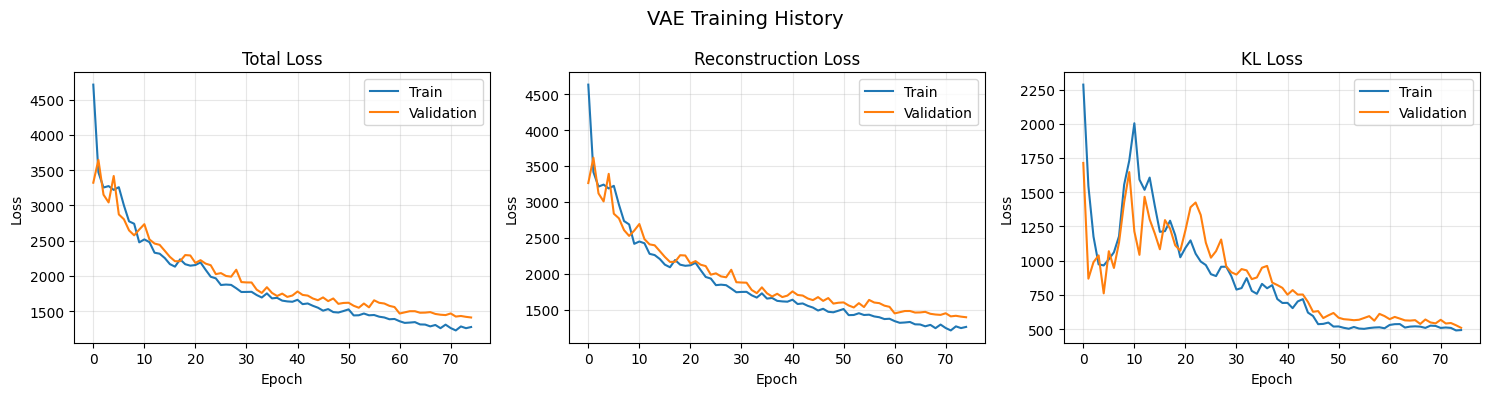

History plot saved to ../reports/figures/training_history.png


In [42]:
plot_history(history)

In [43]:
def evaluate_on_test(
    vae: VAE,
    decoder: keras.Model,
    x_test: np.ndarray,
    n_show: int = 5,
    #save_path: str = "../reports/figures/test_reconstructions.png",
):
    print("\n── Test Set Evaluation ──")
    results = vae.evaluate(x_test, x_test, batch_size=BATCH_SIZE, verbose=1)
    print(f"  total_loss:          {results[0]:.4f}")
    print(f"  reconstruction_loss: {results[1]:.4f}")
    print(f"  kl_loss:             {results[2]:.4f}")

    # Reconstruct images
    n_show = min(n_show, len(x_test))
    samples = x_test[:n_show]
    mu, log_var, z = vae.encoder.predict(samples, verbose=0)
    reconstructed  = decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 5))
    fig.suptitle("Top: Original  |  Bottom: Reconstructed", fontsize=11)

    for i in range(n_show):
        axes[0, i].imshow(np.clip(samples[i], 0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
        axes[1, i].axis("off")

    plt.tight_layout()
    #plt.savefig(save_path, dpi=150)
    plt.show()
    #print(f"Reconstructions saved to {save_path}")


── Test Set Evaluation ──
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - kl_loss: 500.9821 - reconstruction_loss: 1620.3243 - total_loss: 1637.8588
  total_loss:          1637.8588
  reconstruction_loss: 1620.3243
  kl_loss:             500.9821


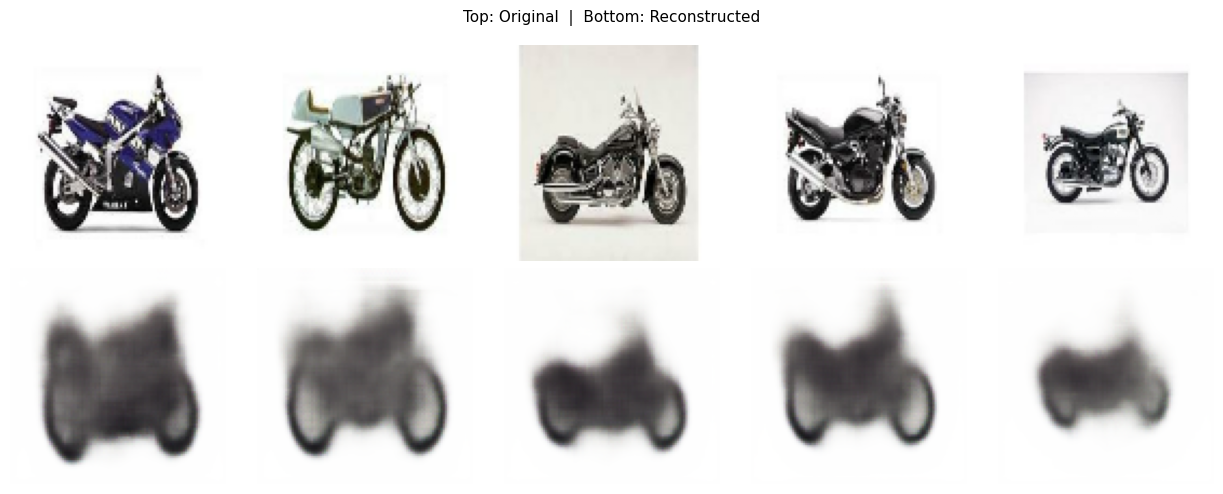

In [44]:
evaluate_on_test(vae, decoder, x_test)

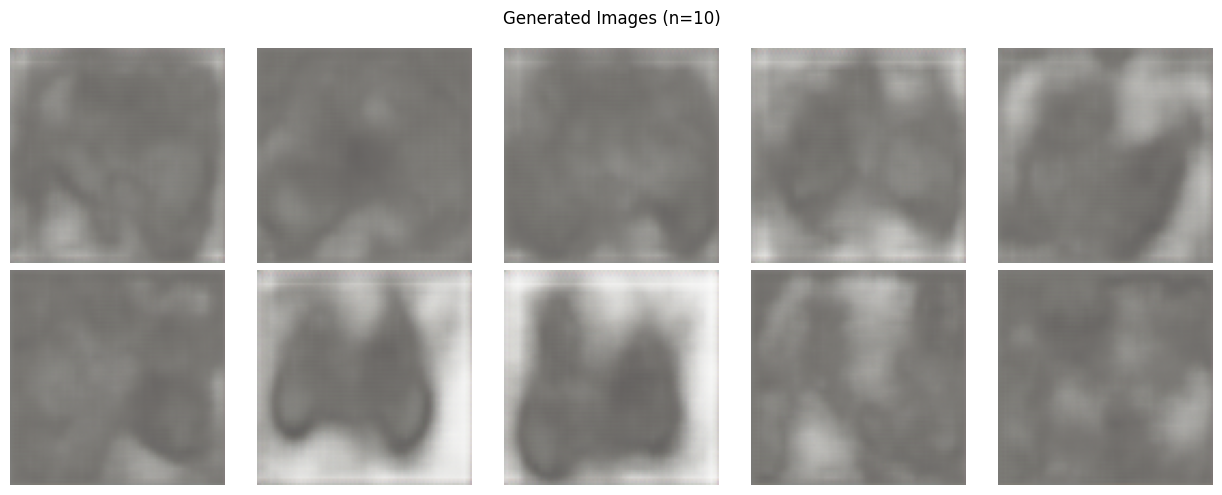

In [45]:
def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"../reports/figures/generated_images_{n_images}.png"
    #plt.savefig(save_path, dpi=150)
    plt.show()
    #print(f"Generated images saved to {save_path}")

generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)